# DecoderTCR V0.3: quick start

Score TCR-pMHC recognition from **V/J genes + CDR3 + HLA allele + peptide**. DecoderTCR
reconstructs the full complex and scores it, so you supply only those components. Higher PLL
means more binder-like, and the default model is `DecoderTCR-ESMC_600M`.

Run on a GPU for speed (it also runs on CPU, just slower). Fetch weights and IMGT germlines
once (see the README setup): `uv run python scripts/download_weights.py` then
`uv run stitchrdl -s human`.


In [1]:
from pathlib import Path

import pandas as pd
import torch

import DecoderTCR as dt
from DecoderTCR.utils.model_zoo import MODEL_ZOO

REPO = Path.cwd().parent if Path.cwd().name == "Demo" else Path.cwd()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
print("models:", list(MODEL_ZOO))

device: cuda
models: ['DecoderTCR-ESMC_6B', 'DecoderTCR-ESMC_600M', 'DecoderTCR-ESMC_300M', 'DecoderTCR_3B', 'DecoderTCR_650M']


## 1. Score a single pair

Supply the TCR's V/J genes and CDR3s, the HLA allele, and the peptide. `score_from_components`
returns a one-row DataFrame with the reconstructed chains and a `pll_<model>` column.

In [2]:
result = dt.score_from_components(
    {"trav": "TRAV21", "traj": "TRAJ6", "cdr3a": "CAVRPGGAGPFFVVF",
     "trbv": "TRBV7-9", "trbj": "TRBJ2-7", "cdr3b": "CASSLGQAYEQYF",
     "hla": "HLA-B*27:05", "peptide": "LRVMMLAPF"},
    device=DEVICE)          # add model="DecoderTCR-ESMC_6B" to override the default
result[["peptide", "hla", "ok", "pll_DecoderTCR-ESMC_600M"]]

,peptide,hla,ok,pll_DecoderTCR-ESMC_600M
0,LRVMMLAPF,HLA-B*27:05,True,-0.062469


## 2. Score a batch from a CSV

Pass a CSV (or a DataFrame, or a list of dicts) of components. Columns are case-insensitive
with aliases: `trav, traj, cdr3a, trbv, trbj, cdr3b, hla, peptide` (optional `name, label`).

Here we score 30 TCRs against two `HLA-A*02:01` viral epitopes (influenza M1 `GILGFVFTL` and
CMV pp65 `NLVPMVATV`), each a mix of known binders and non-binders. The PLL is a per-epitope
ranking, so within each epitope sorting by PLL surfaces the binders, and the per-epitope
AUROC quantifies the separation.


In [3]:
from sklearn.metrics import roc_auc_score

pairs = pd.read_csv(REPO / "Demo/sample_data/genes_pairs.csv")
scored = dt.score_from_components(pairs, device=DEVICE)

ok = scored[scored.ok]
print("per-epitope AUROC (binder vs non-binder):")
for pep, g in ok.groupby("peptide"):
    auc = roc_auc_score(g.label, g["pll_DecoderTCR-ESMC_600M"])
    print(f"  {pep}: {auc:.3f}  ({int(g.label.sum())} binders / {int((g.label == 0).sum())} non)")
scored[["name", "peptide", "label", "ok", "pll_DecoderTCR-ESMC_600M"]].sort_values(
    ["peptide", "pll_DecoderTCR-ESMC_600M"], ascending=[True, False]).head(12)


per-epitope AUROC (binder vs non-binder):
  GILGFVFTL: 0.840  (10 binders / 10 non)
  NLVPMVATV: 0.920  (5 binders / 5 non)


,name,peptide,label,ok,pll_DecoderTCR-ESMC_600M
23,V23,GILGFVFTL,1,True,-0.000592
20,V20,GILGFVFTL,1,True,-0.000600
19,V19,GILGFVFTL,1,True,-0.013361
1,V01,GILGFVFTL,1,True,-0.015674
12,V12,GILGFVFTL,1,True,-0.031005
25,V25,GILGFVFTL,1,True,-0.110431
13,V13,GILGFVFTL,0,True,-0.399696
22,V22,GILGFVFTL,0,True,-0.727222
27,V27,GILGFVFTL,1,True,-0.782141
29,V29,GILGFVFTL,0,True,-0.858039


## 3. From the command line

The same single-pair and batch modes are available on the CLI:

```bash
# single pair (components as flags)
python -m DecoderTCR.utils.predict_from_genes \
    --trav TRAV21 --traj TRAJ6 --cdr3a CAVRPGGAGPFFVVF \
    --trbv TRBV7-9 --trbj TRBJ2-7 --cdr3b CASSLGQAYEQYF \
    --hla 'HLA-B*27:05' --peptide LRVMMLAPF -d cuda:0

# batch (a CSV in, a scored CSV out)
python -m DecoderTCR.utils.predict_from_genes \
    -i Demo/sample_data/genes_pairs.csv -o scored.csv -d cuda:0
```

## 4. Embeddings

`dt.embed` returns backbone embeddings for the reconstructed complexes: mean-pooled per complex
(`pool="mean"`), per region (`pool="regions"`), or per residue (`pool=None`).

In [4]:
emb = dt.embed(scored, device=DEVICE)               # (N, d) mean-pooled per complex
print("mean-pooled embeddings:", emb.shape)

regions = dt.embed(scored, pool="regions", device=DEVICE)
print("regions for pair 0:", {r: v.shape for r, v in regions[0].items()})

per_res = dt.embed(scored, pool=None, device=DEVICE)   # list of (L_i, d), one vector per residue
print("per-residue for pair 0:", per_res[0].shape)

mean-pooled embeddings: (30, 1152)


regions for pair 0: {'HLA_a': (1152,), 'HLA_b': (1152,), 'Peptide': (1152,), 'TCR_a': (1152,), 'TCR_b': (1152,)}


per-residue for pair 0: (1025, 1152)


## 5. Peptide profiles and design

The model also runs in the other direction. Mask the peptide and DecoderTCR predicts what a TCR
and HLA expect to see, so no peptide is supplied, only a length.

Design takes full sequences, so this section starts from `sequence_pairs.csv` rather than the
gene table used above. `dt.peptide_profile` returns the per-position amino-acid distribution from
a single forward pass, plus a per-position `entropy` column. Here it is the HLA-B\*27:05 clone,
with the peptide withheld.


In [5]:
from DecoderTCR.constants import AA20
from DecoderTCR.design.profile import consensus

# Design takes full sequences: HLA_a, HLA_b, TCR_a, TCR_b. No peptide, only a length.
pair = pd.read_csv(REPO / "Demo/sample_data/sequence_pairs.csv").iloc[0]
seqs = {k: pair[k] for k in ("HLA_a", "HLA_b", "TCR_a", "TCR_b")}

prof = dt.peptide_profile(seqs, length=9, device=DEVICE)
print("consensus peptide:", consensus(prof))     # the true epitope is LRVMMLAPF
print("P2 arginine, the B*27:05 anchor:", round(float(prof.loc[2, "R"]), 3))

# prof holds the full 9 x 20 matrix plus entropy. Here are the two most probable residues
# at each position, where a low entropy marks a position the model is confident about.
aa = prof[list(AA20)]
pd.DataFrame({"1st": aa.idxmax(axis=1),
              "p": aa.max(axis=1).round(3),
              "2nd": aa.apply(lambda r: r.nlargest(2).index[-1], axis=1),
              "p2": aa.apply(lambda r: r.nlargest(2).iloc[-1], axis=1).round(3),
              "entropy": prof.entropy.round(2)})


consensus peptide: LRVMMLAPF
P2 arginine, the B*27:05 anchor: 0.975


,1st,p,2nd,p2,entropy
position,,,,,
1,L,0.874,T,0.048,0.61
2,R,0.975,Q,0.022,0.13
3,V,0.991,L,0.006,0.06
4,M,0.969,G,0.011,0.19
5,M,0.916,L,0.055,0.38
6,L,0.781,I,0.158,0.73
7,A,0.996,G,0.002,0.03
8,P,0.995,A,0.003,0.04
9,F,0.982,R,0.009,0.12


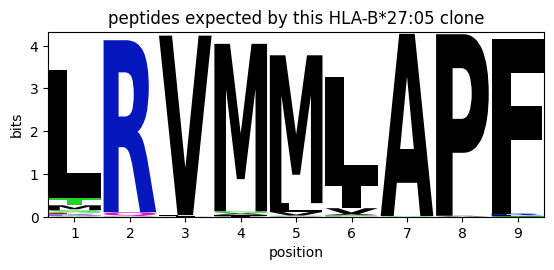

In [6]:
dt.sequence_logo(prof, title="peptides expected by this HLA-B*27:05 clone");

How much of that comes from the TCR rather than the HLA? Profile the same complex again with
the TCR chains removed. The P2 anchor is set by the HLA and survives, while the rest of the
peptide is far less determined, which shows up as higher entropy.

with the TCR : LRVMMLAPF   mean entropy 0.26
HLA alone    : GRLLELPNL   mean entropy 2.29


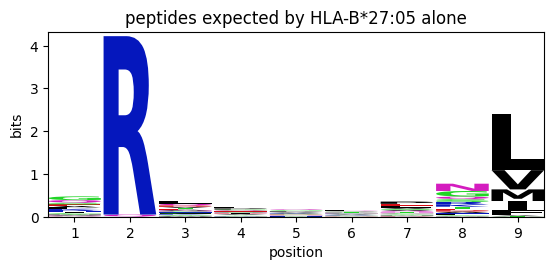

In [7]:
hla_only = {"HLA_a": seqs["HLA_a"], "HLA_b": seqs["HLA_b"]}      # same HLA, no TCR

prof_hla = dt.peptide_profile(hla_only, length=9, device=DEVICE)
print(f"with the TCR : {consensus(prof)}   mean entropy {prof.entropy.mean():.2f}")
print(f"HLA alone    : {consensus(prof_hla)}   mean entropy {prof_hla.entropy.mean():.2f}")
dt.sequence_logo(prof_hla, title="peptides expected by HLA-B*27:05 alone");


`dt.design_peptides` turns the profile into candidate peptides, scored with the same
masked-peptide PLL as section 1 and sorted best first. The default draws each position from its
marginal in one forward pass. Passing `method="iegr"` instead runs Iterative Entropy-Guided
Refinement, the decoding algorithm from the paper: it commits the most confident position
first, then resamples the rest in that context, so it accounts for dependencies between
positions. Lower `temperature` favours likelihood, higher favours diversity.

In [8]:
# design_peptides takes the same full sequences.
one_shot = dt.design_peptides(seqs, length=9, n=8, device=DEVICE)
iegr = dt.design_peptides(seqs, length=9, n=8, method="iegr", temperature=1.0,
                          device=DEVICE)

print("one-shot (single forward pass):")
print(one_shot[["sequence", "pll"]].to_string(index=False))
print("\nIEGR (iterative entropy-guided refinement):")
print(iegr[["sequence", "phase", "pll"]].to_string(index=False))
print(f"\nrequested {one_shot.attrs['n_requested']}, returned {one_shot.attrs['n_returned']}, saturated={one_shot.attrs['saturated']}")


one-shot (single forward pass):
 sequence       pll
LRVMMLAPF -0.062469
LRVMMIAPF -0.239937
TRVMMLAPF -0.384376
LRVMMVAPF -0.388822
MRVMMLAPF -0.424936
LRVMVLAPF -0.482126
LQVMMLAPF -0.483541
TRVMMIAPF -0.561844

IEGR (iterative entropy-guided refinement):
 sequence  phase       pll
LRVMMLAPF      2 -0.062469
TRVMMIAPF      2 -0.561844
LRVLMLAPF      1 -0.648009
MRVGMLAPF      2 -0.924860
TRVMMPAPF      2 -0.972846
LRVTMSAPF      2 -1.319151
LRFMMLGPF      2 -1.639779
KRAGMLAPF      2 -2.060815

requested 8, returned 8, saturated=False


## 6. Benchmark results

See [`../results/`](../results/) for all figures and per-model CSVs. The cross-benchmark
summary at a glance:

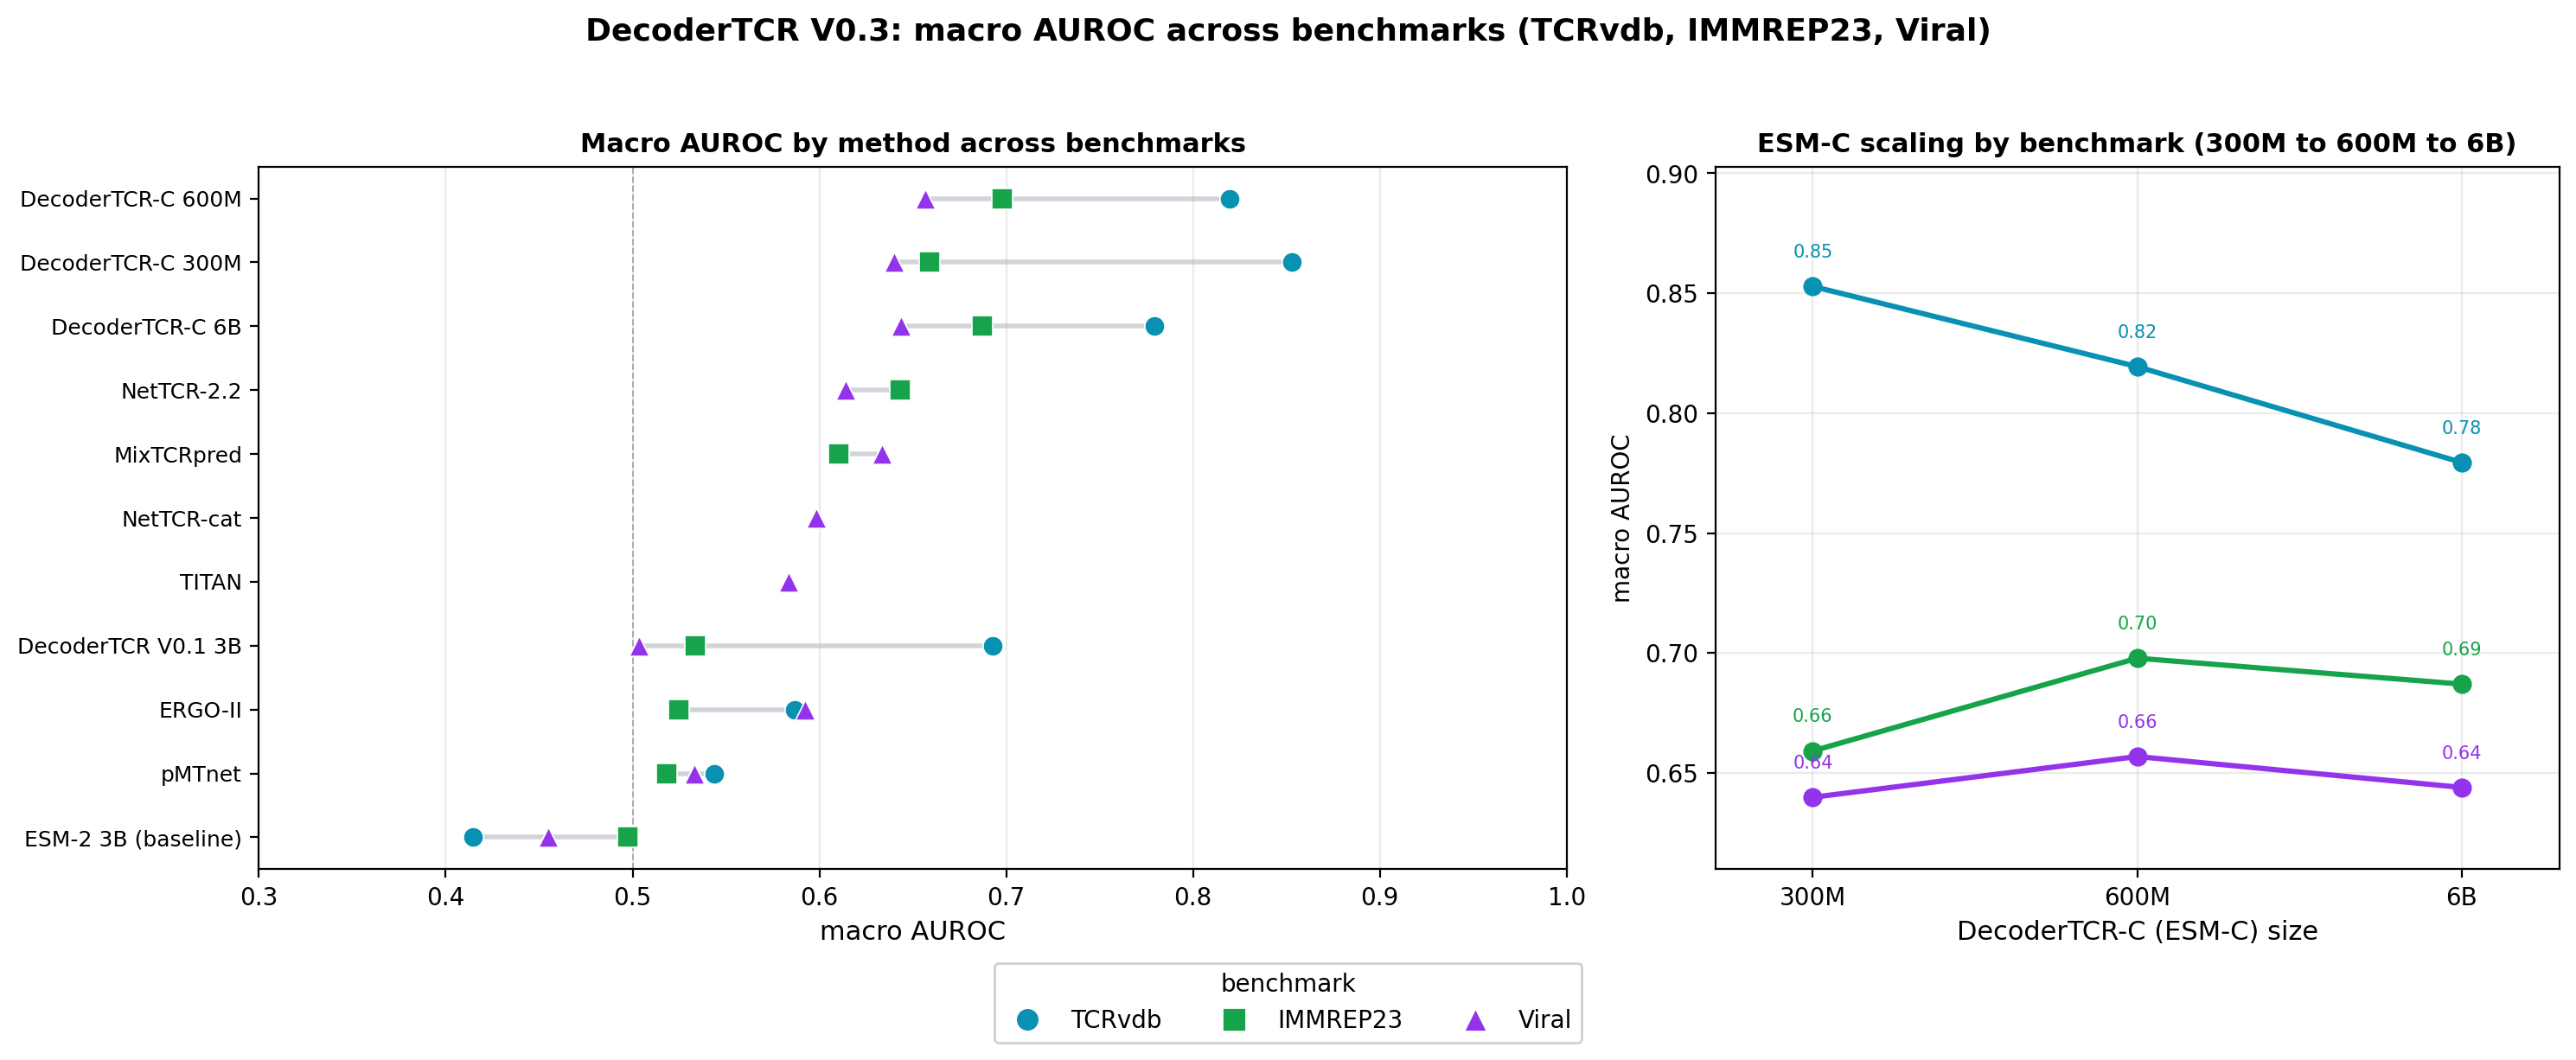

In [9]:
from IPython.display import Image
Image(filename=str(REPO / "results/figures/summary_dotplot_scaling.png"))